In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the NAV data
df = pd.read_csv("../data/raw/HDFC_Top100_NAV.csv")

# Display first few rows
df.head()

,date,nav
0,25-06-2026,203.9157
1,24-06-2026,205.0655
2,23-06-2026,203.5443
3,22-06-2026,204.1263
4,19-06-2026,202.0761


In [3]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df = df.sort_values("date")

df.head()

,date,nav
3108,2013-11-18,13.0894
3107,2013-11-19,13.1068
3106,2013-11-20,12.9549
3105,2013-11-21,12.7957
3104,2013-11-22,12.7775


In [4]:
df["daily_return"] = df["nav"].pct_change()

df.head()

,date,nav,daily_return
3108,2013-11-18,13.0894,NaN
3107,2013-11-19,13.1068,0.001329
3106,2013-11-20,12.9549,-0.011589
3105,2013-11-21,12.7957,-0.012289
3104,2013-11-22,12.7775,-0.001422


In [5]:
df["daily_return"].describe()

count    3108.000000
mean        0.000930
std         0.009574
min        -0.096964
25%        -0.003340
50%         0.001502
75%         0.006263
max         0.046026
Name: daily_return, dtype: float64

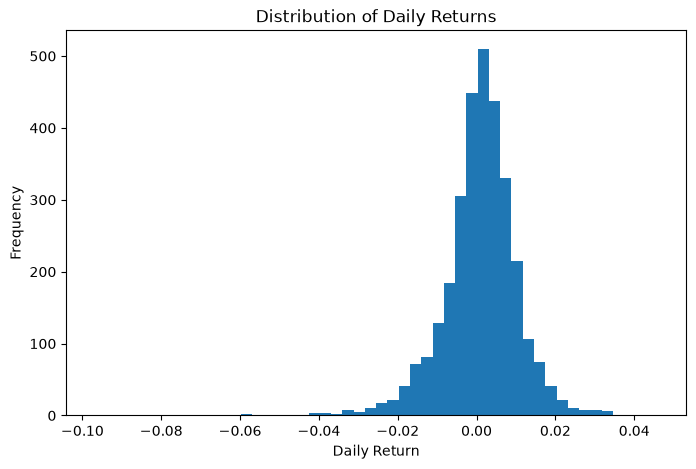

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [8]:
df = pd.read_csv("../data/raw/HDFC_Top100_NAV.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df = df.sort_values("date")

df.head()

,date,nav
3108,2013-11-18,13.0894
3107,2013-11-19,13.1068
3106,2013-11-20,12.9549
3105,2013-11-21,12.7957
3104,2013-11-22,12.7775


In [9]:
df["Daily_Return"] = df["nav"].pct_change()

df.head()

,date,nav,Daily_Return
3108,2013-11-18,13.0894,NaN
3107,2013-11-19,13.1068,0.001329
3106,2013-11-20,12.9549,-0.011589
3105,2013-11-21,12.7957,-0.012289
3104,2013-11-22,12.7775,-0.001422


In [10]:
df["Cumulative_Return"] = (1 + df["Daily_Return"]).cumprod()

df.head()

,date,nav,Daily_Return,Cumulative_Return
3108,2013-11-18,13.0894,NaN,NaN
3107,2013-11-19,13.1068,0.001329,1.001329
3106,2013-11-20,12.9549,-0.011589,0.989725
3105,2013-11-21,12.7957,-0.012289,0.977562
3104,2013-11-22,12.7775,-0.001422,0.976172


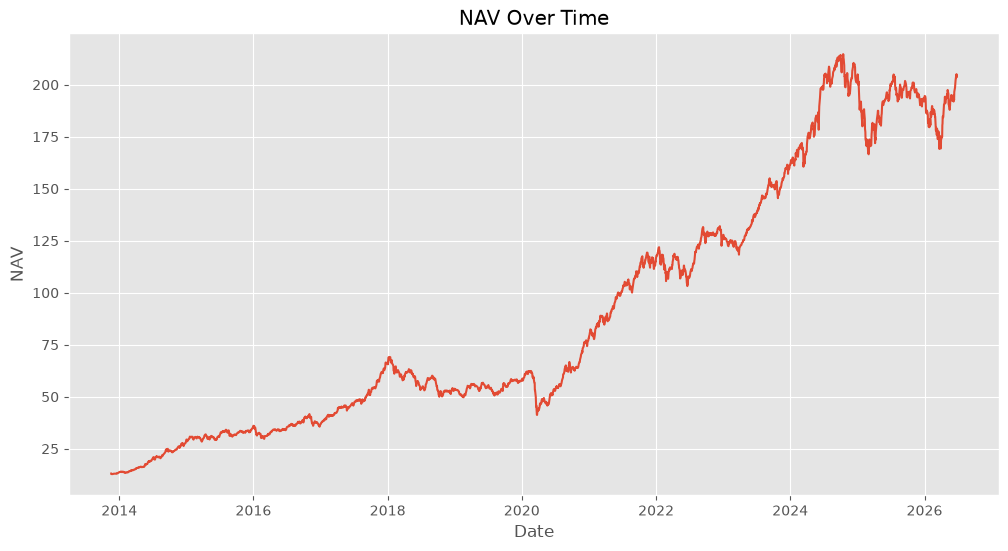

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["nav"])

plt.title("NAV Over Time")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

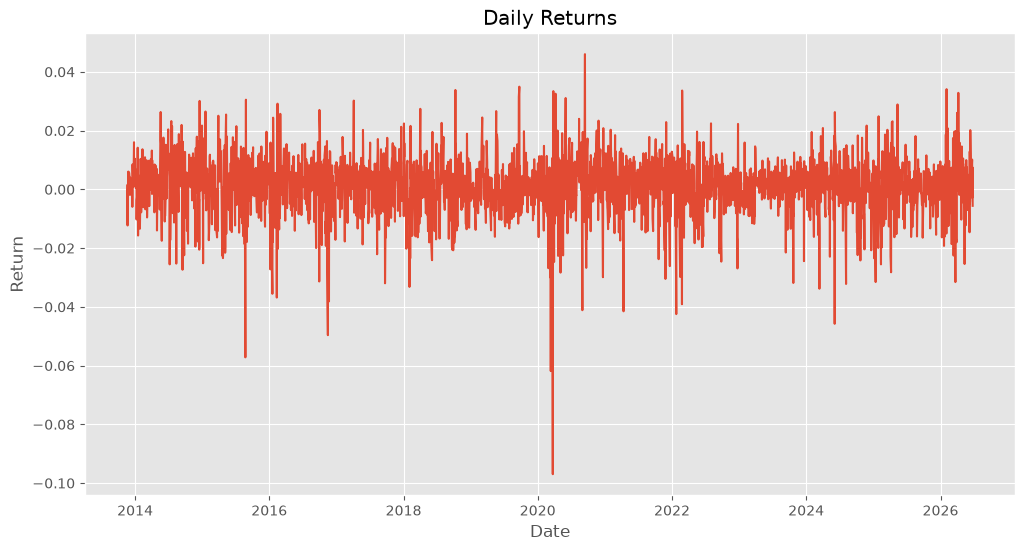

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["Daily_Return"])

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

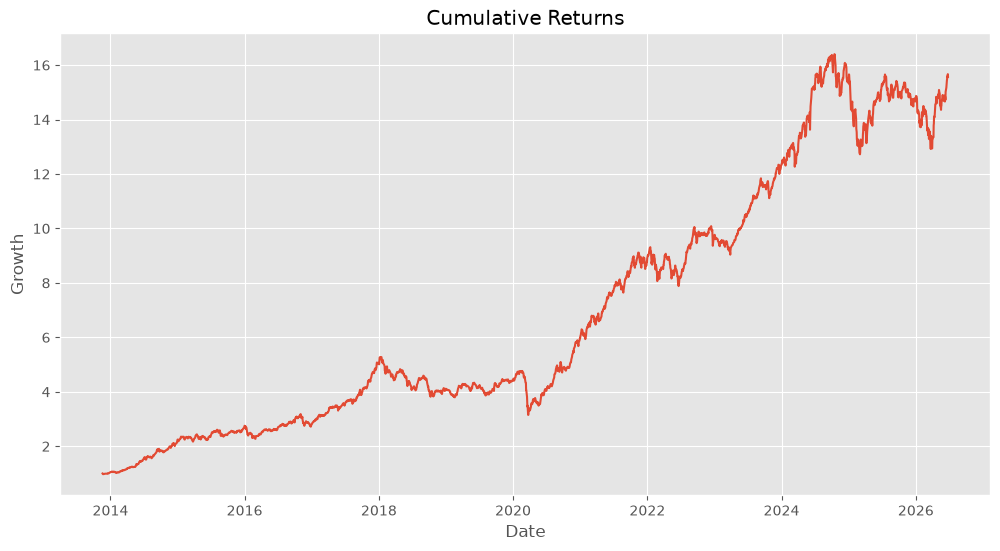

In [13]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["Cumulative_Return"])

plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth")

plt.show()

In [14]:
print("Average Daily Return :", df["Daily_Return"].mean())
print("Maximum Daily Return :", df["Daily_Return"].max())
print("Minimum Daily Return :", df["Daily_Return"].min())
print("Volatility :", df["Daily_Return"].std())

Average Daily Return : 0.0009299735633935462
Maximum Daily Return : 0.046025829249845884
Minimum Daily Return : -0.09696415924173929
Volatility : 0.009574390004080323


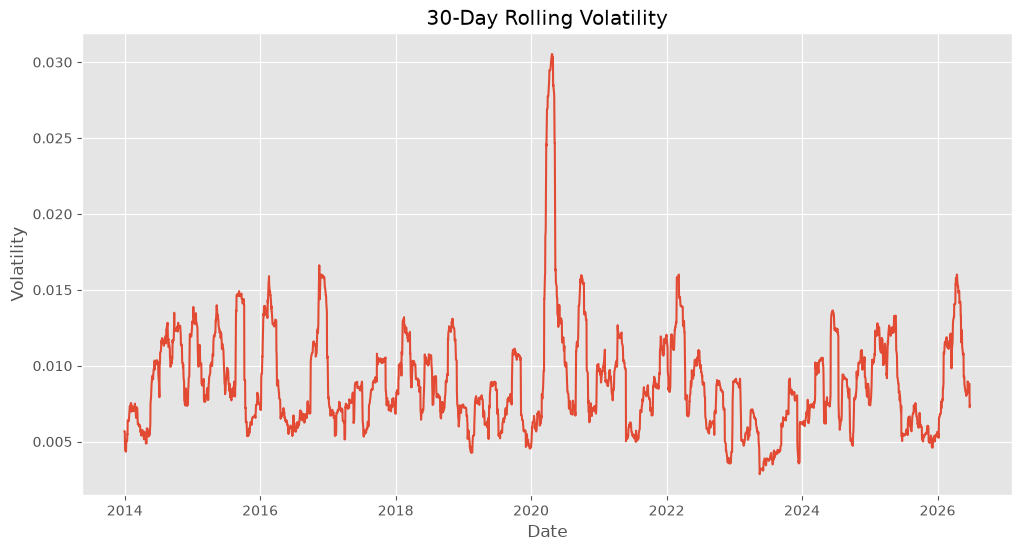

In [15]:
df["Rolling_Volatility"] = df["Daily_Return"].rolling(30).std()

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["Rolling_Volatility"])

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

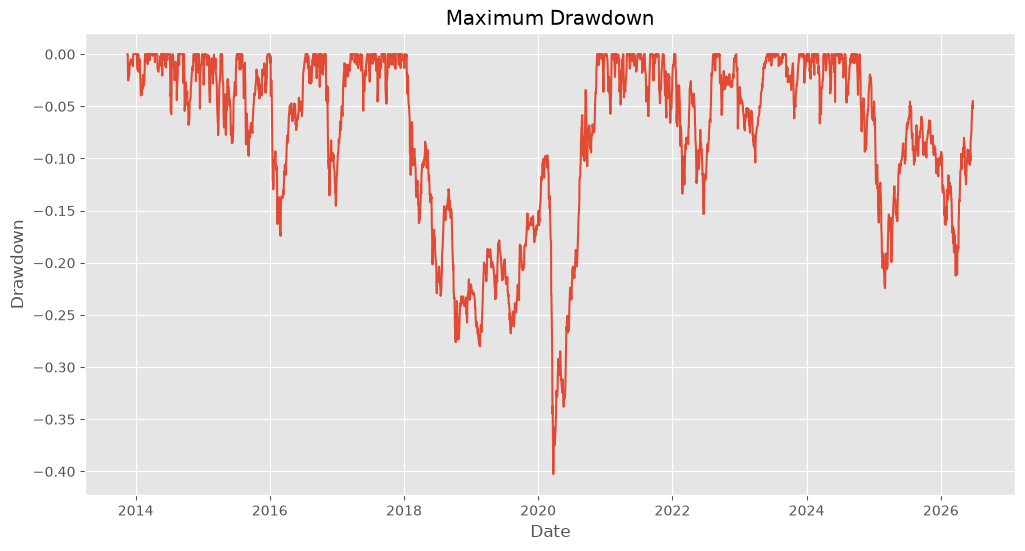

In [16]:
df["Running_Max"] = df["nav"].cummax()

df["Drawdown"] = (df["nav"] - df["Running_Max"]) / df["Running_Max"]

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["Drawdown"])

plt.title("Maximum Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.show()